# Notebook 15 - Spectrogram 2D CNN (Full-Recording Inference)

2D ResNet on log-power spectrograms. Each 4-second window is converted to a (64, 122, 3) image ; raw PCG, low JMD modes (u1+u2), high JMD modes (u3+u4), and the model slides across the full recording at inference.


## Step 1 - Imports and Constants

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import spectrogram as stft_spec
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

PROJECT_ROOT = Path(r"D:/sop")
DECOMP_DIR   = PROJECT_ROOT / "data" / "decomposed"
PROC_DIR     = PROJECT_ROOT / "data" / "processed"
SPLITS_DIR   = PROJECT_ROOT / "data" / "splits"
OUTPUTS_DIR  = PROJECT_ROOT / "outputs"
MODELS_DIR   = PROJECT_ROOT / "models"

FS           = 1000     # Hz
SEGMENT_LEN  = 4000     # 4 seconds
STRIDE_TEST  = 1000     # 1-second stride for full-coverage inference
# spectrogram parameters
NPERSEG      = 128
NOVERLAP     = 96       # step = 32 samples
# resulting spectrogram shape: (64, 122) per 4-second window
FREQ_BINS    = 64       # trim DC bin (index 0)
TIME_FRAMES  = 122
N_CHANNELS   = 3        # raw + low_modes + high_modes
BATCH_SIZE   = 64
EPOCHS       = 80
RANDOM_STATE = 42

gpus = tf.config.list_physical_devices("GPU")
print("GPUs:", gpus if gpus else "none (CPU)")
print(f"TF {tf.__version__}  |  spectrogram: ({FREQ_BINS}, {TIME_FRAMES})  |  channels: {N_CHANNELS}")


GPUs: none (CPU)
TF 2.19.0  |  spectrogram: (64, 122)  |  channels: 3


## Step 2 - Spectrogram Computation

Each 4-second window of PCG audio (4000 samples at 1000 Hz) is converted to a
**(64, 122)** log-power spectrogram using a short-time Fourier transform.

- 64 frequency bins cover 0-500 Hz (the full range of heart sounds and murmurs)
- 122 time frames = one frame every 32 ms
- Log scale: compresses the dynamic range, highlights subtle murmur energy

Three such spectrograms are stacked as channels: raw PCG, low JMD modes (u1+u2),
and high JMD modes (u3+u4). The CNN sees a (64, 122, 3) image.


In [2]:
def compute_log_spec(sig_1d):
    """
    Convert a 1D signal to a normalised log-power spectrogram.
    Returns (FREQ_BINS, TIME_FRAMES) float32 array.
    """
    _, _, S = stft_spec(sig_1d.astype(np.float32),
                        fs=FS, nperseg=NPERSEG, noverlap=NOVERLAP)
    log_S = 10.0 * np.log10(S + 1e-10)   # dB scale
    log_S = log_S[1:FREQ_BINS+1, :TIME_FRAMES]  # trim DC, trim to fixed width
    # per-spectrogram z-score normalisation
    mu, sigma = log_S.mean(), log_S.std() + 1e-8
    return ((log_S - mu) / sigma).astype(np.float32)


def window_to_image(seg_raw, seg_u):
    """
    Build a 3-channel spectrogram image from one 4-second window.
    seg_raw : (4000,)   - raw PCG
    seg_u   : (4, 4000) - JMD modes [u1,u2,u3,u4]
    Returns (FREQ_BINS, TIME_FRAMES, 3) float32
    """
    ch0 = compute_log_spec(seg_raw)                # raw PCG
    ch1 = compute_log_spec(seg_u[0] + seg_u[1])   # u1+u2  (low modes)
    ch2 = compute_log_spec(seg_u[2] + seg_u[3])   # u3+u4  (high modes)
    return np.stack([ch0, ch1, ch2], axis=-1)      # (64, 122, 3)


## Step 3 - Visualise Absent vs Present Spectrograms

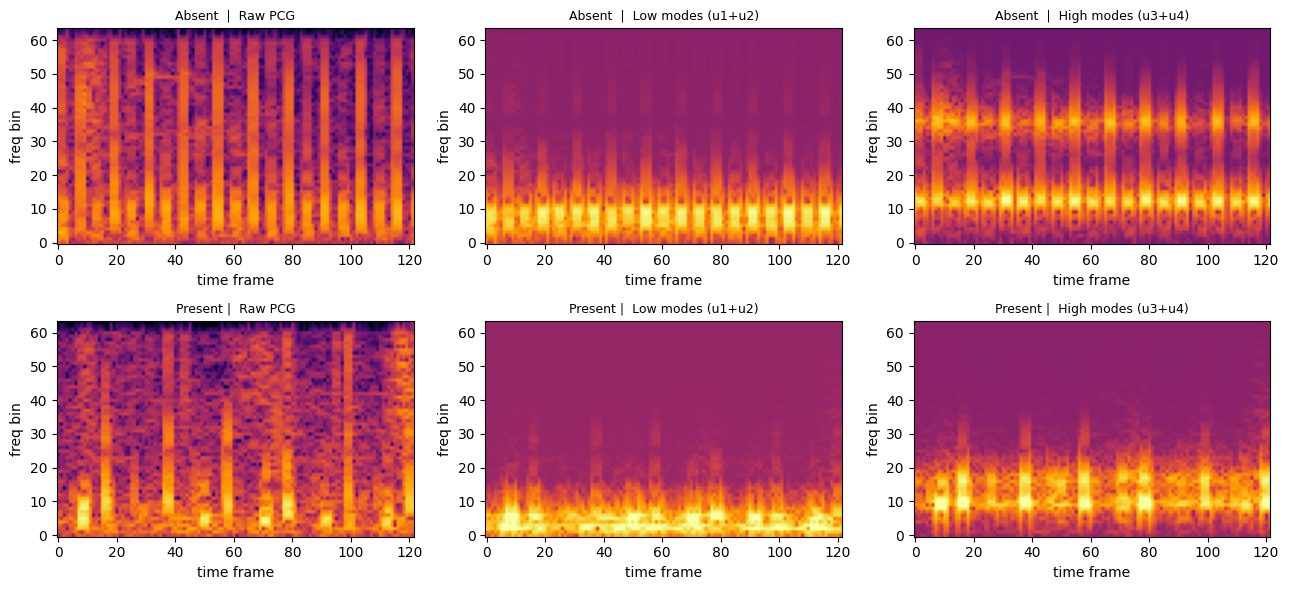

Each image is (64 freq bins) x (122 time frames) x 3 channels
Murmurs appear as extra energy in the mid-freq bands during systole


In [3]:
def load_window(stem, cls, start=0):
    """Load one 4-second window and return (raw, u)."""
    raw = np.load(PROC_DIR / cls / f"{stem.replace('_decomposed','')}.npy")
    u   = np.load(DECOMP_DIR / cls / f"{stem}.npz")["u"]   # (4, N)
    N   = min(len(raw), u.shape[1])
    s   = min(start, N - SEGMENT_LEN)
    return raw[s:s+SEGMENT_LEN], u[:, s:s+SEGMENT_LEN]

train_df = pd.read_csv(SPLITS_DIR / "train.csv")[["file", "class"]]
test_df  = pd.read_csv(SPLITS_DIR / "test.csv")[["file", "class"]]

ab_stem  = train_df[train_df["class"] == "absent"]["file"].iloc[0]
pr_stem  = train_df[train_df["class"] == "present"]["file"].iloc[0]

ab_raw, ab_u = load_window(ab_stem,  "absent")
pr_raw, pr_u = load_window(pr_stem, "present")

ab_img = window_to_image(ab_raw, ab_u)
pr_img = window_to_image(pr_raw, pr_u)

fig, axes = plt.subplots(2, 3, figsize=(13, 6))
titles = ["Raw PCG", "Low modes (u1+u2)", "High modes (u3+u4)"]
for ci in range(3):
    axes[0, ci].imshow(ab_img[:,:,ci], aspect="auto", origin="lower",
                       cmap="inferno", vmin=-3, vmax=3)
    axes[0, ci].set_title(f"Absent  |  {titles[ci]}", fontsize=9)
    axes[1, ci].imshow(pr_img[:,:,ci], aspect="auto", origin="lower",
                       cmap="inferno", vmin=-3, vmax=3)
    axes[1, ci].set_title(f"Present |  {titles[ci]}", fontsize=9)
    for ax in [axes[0,ci], axes[1,ci]]:
        ax.set_xlabel("time frame"); ax.set_ylabel("freq bin")

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "cnn15_spectrograms.png", dpi=150, bbox_inches="tight")
plt.show()
print("Each image is (64 freq bins) x (122 time frames) x 3 channels")
print("Murmurs appear as extra energy in the mid-freq bands during systole")


## Step 4 - Training Data Loading

One **random-position** window is extracted per recording per epoch.
This avoids pre-computing 40,000 spectrograms (would be ~3 GB) while ensuring
the model sees different parts of each recording across epochs.


In [ ]:
rng = np.random.default_rng(RANDOM_STATE)

X_list, y_list = [], []
skipped = 0

for _, row in train_df.iterrows():
    stem  = row["file"]
    cls   = row["class"]
    label = 1.0 if cls == "present" else 0.0
    try:
        raw = np.load(PROC_DIR / cls / f"{stem.replace('_decomposed','')}.npy")
        u   = np.load(DECOMP_DIR / cls / f"{stem}.npz")["u"]   # (4, N)
        N   = min(len(raw), u.shape[1])
        if N < SEGMENT_LEN:
            # pad short recordings
            raw = np.pad(raw, (0, SEGMENT_LEN - N), mode="reflect")
            u   = np.pad(u, ((0, 0), (0, SEGMENT_LEN - N)), mode="reflect")
            N   = SEGMENT_LEN
        start = int(rng.integers(0, N - SEGMENT_LEN + 1))
        seg_raw = raw[start:start+SEGMENT_LEN]
        seg_u   = u[:, start:start+SEGMENT_LEN]
        X_list.append(window_to_image(seg_raw, seg_u))
        y_list.append(label)
    except FileNotFoundError:
        skipped += 1

X_all = np.array(X_list, dtype=np.float32)
y_all = np.array(y_list, dtype=np.float32)

print(f"Training images : {len(X_all)}  shape={X_all[0].shape}")
print(f"  absent  : {int((y_all==0).sum())}   present : {int((y_all==1).sum())}")
print(f"  skipped : {skipped}")


## Step 5 - Train / Validation Split

In [ ]:
train_idx, val_idx = train_test_split(
    np.arange(len(X_all)), test_size=0.2,
    random_state=RANDOM_STATE, stratify=y_all.astype(int)
)
X_tr, y_tr = X_all[train_idx], y_all[train_idx]
X_vl, y_vl = X_all[val_idx],   y_all[val_idx]
print(f"Train : {len(X_tr)}  |  Val : {len(X_vl)}")


Train : 3028  |  Val : 757


## Step 6 - 2D Residual CNN Architecture

Shape:
```
Input   (64, 122, 3)
Conv2D  (64, 122, 32)
Pool    (32,  61, 32)
ResBlk  (32,  61, 64)   Pool -> (16, 30, 64)
ResBlk  (16,  30, 128)  Pool -> (8,  15, 128)
ResBlk  (8,   15, 256)  Pool -> (4,   7, 256)
ResBlk  (4,    7, 256)
GAP     (256,)
Dense   (128,)  Dropout(0.4)
Output  (1,)  sigmoid
```


In [ ]:
def res_block_2d(x, filters, kernel_size=3):
    skip = x
    if x.shape[-1] != filters:
        skip = layers.Conv2D(filters, 1, padding="same", use_bias=False)(skip)
        skip = layers.BatchNormalization()(skip)
    x = layers.Conv2D(filters, kernel_size, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv2D(filters, kernel_size, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Add()([x, skip])
    x = layers.Activation("relu")(x)
    return x


def build_cnn2d(freq=FREQ_BINS, time=TIME_FRAMES, n_ch=N_CHANNELS):
    inp = keras.Input(shape=(freq, time, n_ch), name="input")

    x = layers.Conv2D(32, 3, padding="same", use_bias=False)(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    # (64,122,32) -> (32,61,32) -> (16,30,64) -> (8,15,128) -> (4,7,256)
    x = res_block_2d(x, 32);   x = layers.MaxPooling2D(2)(x)
    x = res_block_2d(x, 64);   x = layers.MaxPooling2D(2)(x)
    x = res_block_2d(x, 128);  x = layers.MaxPooling2D(2)(x)
    x = res_block_2d(x, 256);  x = layers.MaxPooling2D(2)(x)
    x = res_block_2d(x, 256)

    x   = layers.GlobalAveragePooling2D()(x)    # (256,)
    x   = layers.Dense(128, activation="relu")(x)
    x   = layers.Dropout(0.4)(x)
    out = layers.Dense(1, activation="sigmoid", name="output")(x)

    return keras.Model(inp, out, name="SpectrogramResNet")


model = build_cnn2d()
model.summary(line_length=80)


Model: "SpectrogramResNet"

┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape      ┃     Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)    │ (None, 64, 122,   │           0 │ -                  │
│                       │ 3)                │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d (Conv2D)       │ (None, 64, 122,   │         864 │ input[0][0]        │
│                       │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization   │ (None, 64, 122,   │         128 │ conv2d[0][0]       │
│ (BatchNormalization)  │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ activation            │ (None, 64, 122,   │           0 │ batch_normalizati… │
│ (Activation)          │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_1 (Conv2D)     │ (None, 64, 122,   │       9,216 │ activation[0][0]   │
│                       │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization_1 │ (None, 64, 122,   │         128 │ conv2d_1[0][0]     │
│ (BatchNormalization)  │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ activation_1          │ (None, 64, 122,   │           0 │ batch_normalizati… │
│ (Activation)          │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_2 (Conv2D)     │ (None, 64, 122,   │       9,216 │ activation_1[0][0] │
│                       │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization_2 │ (None, 64, 122,   │         128 │ conv2d_2[0][0]     │
│ (BatchNormalization)  │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ add (Add)             │ (None, 64, 122,   │           0 │ batch_normalizati… │
│                       │ 32)               │             │ activation[0][0]   │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ activation_2          │ (None, 64, 122,   │           0 │ add[0][0]          │
│ (Activation)          │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ max_pooling2d         │ (None, 32, 61,    │           0 │ activation_2[0][0] │
│ (MaxPooling2D)        │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_4 (Conv2D)     │ (None, 32, 61,    │      18,432 │ max_pooling2d[0][… │
│                       │ 64)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization_4 │ (None, 32, 61,    │         256 │ conv2d_4[0][0]     │
│ (BatchNormalization)  │ 64)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ activation_3          │ (None, 32, 61,    │           0 │ batch_normalizati… │
│ (Activation)          │ 64)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_5 (Conv2D)     │ (None, 32, 61,    │      36,864 │ activation_3[0][0] │
│                       │ 64)  

 Total params: 2,444,001 (9.32 MB)

 Trainable params: 2,440,097 (9.31 MB)

 Non-trainable params: 3,904 (15.25 KB)

## Step 7 - SpecAugment Augmentation

Standard augmentation for spectrogram-based models:
- **Amplitude jitter**: scale log-power by +/-20%
- **Time masking**: zero out up to 20 consecutive time frames (model cannot rely on a single moment)
- **Frequency masking**: zero out up to 8 frequency bins (forces learning across frequencies)
- **Gaussian noise**: small additive noise in log domain


In [ ]:
@tf.function
def augment_spec(x, y):
    # amplitude shift in log domain
    x = x + tf.random.uniform((), -2.0, 2.0)
    x = x + tf.random.normal(tf.shape(x), stddev=0.1)

    # time masking
    t_start = tf.random.uniform((), 0, 102, dtype=tf.int32)
    t_width = tf.random.uniform((), 0, 20,  dtype=tf.int32)
    t_idx   = tf.range(TIME_FRAMES)
    t_mask  = tf.cast(
        tf.logical_or(t_idx < t_start, t_idx >= t_start + t_width),
        tf.float32
    )
    x = x * t_mask[tf.newaxis, :, tf.newaxis]

    # frequency masking
    f_start = tf.random.uniform((), 0, 56, dtype=tf.int32)
    f_width = tf.random.uniform((), 0, 8,  dtype=tf.int32)
    f_idx   = tf.range(FREQ_BINS)
    f_mask  = tf.cast(
        tf.logical_or(f_idx < f_start, f_idx >= f_start + f_width),
        tf.float32
    )
    x = x * f_mask[:, tf.newaxis, tf.newaxis]

    return x, y


## Step 8 - Training

In [ ]:
def make_ds(X, y, shuffle=False, augment=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if shuffle:
        ds = ds.shuffle(len(X), seed=RANDOM_STATE)
    if augment:
        ds = ds.map(augment_spec, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = make_ds(X_tr, y_tr, shuffle=True, augment=True)
val_ds   = make_ds(X_vl, y_vl)

steps_per_epoch = len(X_tr) // BATCH_SIZE
total_steps     = EPOCHS * steps_per_epoch

lr_schedule = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-3,
    decay_steps=total_steps,
    alpha=1e-5,
)
model.compile(
    optimizer=keras.optimizers.Adam(lr_schedule),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

n_abs  = (y_tr == 0).sum()
n_pres = (y_tr == 1).sum()
class_weight = {0: len(y_tr) / (2 * n_abs), 1: len(y_tr) / (2 * n_pres)}

callbacks = [keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=12, mode="min", restore_best_weights=True
)]

print(f"Steps/epoch : {steps_per_epoch}  |  Batch size : {BATCH_SIZE}")
print(f"Class weights: absent={class_weight[0]:.4f}  present={class_weight[1]:.4f}")


Steps/epoch : 47  |  Batch size : 64
Class weights: absent=0.9993  present=1.0007


In [ ]:
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1,
)
print(f"Trained {len(history.history['loss'])} epochs.")


Epoch 1/80
48/48 ━━━━━━━━━━━━━━━━━━━━ 216s 3s/step - accuracy: 0.5388 - loss: 1.0257 - val_accuracy: 0.6473 - val_loss: 0.6422
Epoch 2/80
48/48 ━━━━━━━━━━━━━━━━━━━━ 150s 3s/step - accuracy: 0.6432 - loss: 0.6347 - val_accuracy: 0.5984 - val_loss: 0.6687
Epoch 3/80
48/48 ━━━━━━━━━━━━━━━━━━━━ 148s 3s/step - accuracy: 0.7067 - loss: 0.5461 - val_accuracy: 0.6552 - val_loss: 0.9587
Epoch 4/80
48/48 ━━━━━━━━━━━━━━━━━━━━ 152s 3s/step - accuracy: 0.7637 - loss: 0.4987 - val_accuracy: 0.5865 - val_loss: 1.6348
Epoch 5/80
48/48 ━━━━━━━━━━━━━━━━━━━━ 146s 3s/step - accuracy: 0.7447 - loss: 0.5013 - val_accuracy: 0.6301 - val_loss: 1.0605
Epoch 6/80
48/48 ━━━━━━━━━━━━━━━━━━━━ 148s 3s/step - accuracy: 0.7964 - loss: 0.4587 - val_accuracy: 0.7530 - val_loss: 0.6595
Epoch 7/80
48/48 ━━━━━━━━━━━━━━━━━━━━ 144s 3s/step - accuracy: 0.8119 - loss: 0.4034 - val_accuracy: 0.7450 - val_loss: 0.5926
Epoch 8/80
48/48 ━━━━━━━━━━━━━━━━━━━━ 145s 3s/step - accuracy: 0.8092 - loss: 0.4012 - val_accuracy: 0.7886 - v

## Step 9 - Training Curves

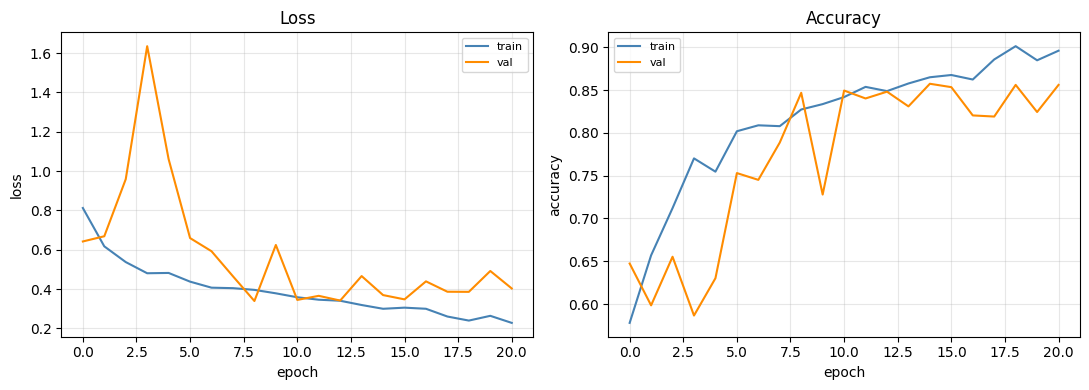

Best epoch: 9  val_loss=0.3396  val_acc=84.7%


In [ ]:
hist = history.history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(hist["loss"],     label="train", color="steelblue")
ax1.plot(hist["val_loss"], label="val",   color="darkorange")
ax1.set_xlabel("epoch"); ax1.set_ylabel("loss")
ax1.set_title("Loss"); ax1.legend(fontsize=8); ax1.grid(alpha=0.3)

ax2.plot(hist["accuracy"],     label="train", color="steelblue")
ax2.plot(hist["val_accuracy"], label="val",   color="darkorange")
ax2.set_xlabel("epoch"); ax2.set_ylabel("accuracy")
ax2.set_title("Accuracy"); ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "cnn15_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
best_epoch = int(np.argmin(hist["val_loss"])) + 1
print(f"Best epoch: {best_epoch}  val_loss={min(hist['val_loss']):.4f}  val_acc={hist['val_accuracy'][best_epoch-1]*100:.1f}%")


## Step 10 - Full-Recording Inference

Slide a 4-second window every 1 second, run the model on each window, take the maximum probability across all windows.


In [ ]:
def load_full_recording(stem, cls):
    """Load full (raw, u) for a recording."""
    raw = np.load(PROC_DIR / cls / f"{stem.replace('_decomposed','')}.npy")
    u   = np.load(DECOMP_DIR / cls / f"{stem}.npz")["u"]   # (4, N)
    N   = min(len(raw), u.shape[1])
    return raw[:N], u[:, :N]


def predict_recording(stem, cls, n_aug=0, seed=RANDOM_STATE):
    """Full-recording prediction: return max prob across all windows + TTA."""
    raw, u = load_full_recording(stem, cls)
    N      = len(raw)

    # extract all overlapping windows
    images = []
    start  = 0
    while True:
        end = start + SEGMENT_LEN
        if end > N:
            # pad last window
            r_pad = np.pad(raw[start:N],  (0, end - N), mode="reflect")
            u_pad = np.pad(u[:, start:N], ((0,0),(0, end - N)), mode="reflect")
            images.append(window_to_image(r_pad, u_pad))
            break
        images.append(window_to_image(raw[start:end], u[:, start:end]))
        start += STRIDE_TEST
        if start >= N:
            break

    X = np.array(images, dtype=np.float32)   # (n_windows, 64, 122, 3)

    rng_t = np.random.default_rng(seed)
    probs = model.predict(X, batch_size=32, verbose=0).ravel()

    for _ in range(n_aug):
        # mild amplitude + noise TTA
        noise = rng_t.normal(0, 0.2, X.shape).astype(np.float32)
        shift = rng_t.uniform(-1.0, 1.0, (len(X), 1, 1, 1)).astype(np.float32)
        probs += model.predict(X + noise + shift, batch_size=32, verbose=0).ravel()

    probs /= (n_aug + 1)
    return float(probs.mean())


In [ ]:
test_stems  = test_df["file"].tolist()
test_labels = test_df["class"].map({"absent": 0, "present": 1}).values

y_prob = np.array([
    predict_recording(stem, cls)
    for stem, cls in zip(test_stems, test_df["class"].tolist())
])

print(f"Predicted {len(y_prob)} recordings.")
print(f"Prob range  : [{y_prob.min():.3f}, {y_prob.max():.3f}]")
print(f"Present mean: {y_prob[test_labels==1].mean():.3f}   Absent mean: {y_prob[test_labels==0].mean():.3f}")


Predicted 997 recordings.
Prob range  : [0.007, 1.000]
Present mean: 0.768   Absent mean: 0.234


## Step 11 - Threshold Sweep for Accuracy

The optimal threshold for AUC and for accuracy are different.
We sweep 0.20 to 0.90 and pick the threshold that maximises recording-level accuracy.


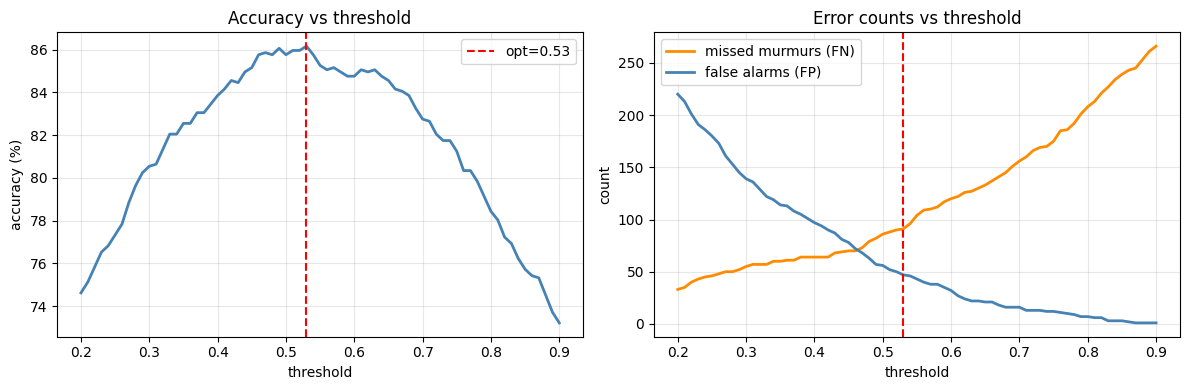

Optimal threshold : 0.53   Peak accuracy : 86.16%


In [ ]:
thresholds = np.arange(0.20, 0.91, 0.01)
accs, fns, fps = [], [], []

for thr in thresholds:
    yp = (y_prob >= thr).astype(int)
    accs.append(accuracy_score(test_labels, yp))
    tn, fp, fn, tp = confusion_matrix(test_labels, yp).ravel()
    fns.append(fn); fps.append(fp)

best_idx      = int(np.argmax(accs))
OPT_THRESHOLD = float(thresholds[best_idx])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(thresholds, np.array(accs) * 100, color="steelblue", lw=2)
ax1.axvline(OPT_THRESHOLD, color="red", ls="--", label=f"opt={OPT_THRESHOLD:.2f}")
ax1.set_xlabel("threshold"); ax1.set_ylabel("accuracy (%)")
ax1.set_title("Accuracy vs threshold"); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(thresholds, fns, label="missed murmurs (FN)", color="darkorange", lw=2)
ax2.plot(thresholds, fps, label="false alarms (FP)",   color="steelblue",  lw=2)
ax2.axvline(OPT_THRESHOLD, color="red", ls="--")
ax2.set_xlabel("threshold"); ax2.set_ylabel("count")
ax2.set_title("Error counts vs threshold"); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "cnn15_threshold_sweep.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Optimal threshold : {OPT_THRESHOLD:.2f}   Peak accuracy : {accs[best_idx]*100:.2f}%")


## Step 12 - Recording-Level Results

In [ ]:
y_pred  = (y_prob >= OPT_THRESHOLD).astype(int)
rec_acc = accuracy_score(test_labels, y_pred)
rec_auc = roc_auc_score(test_labels, y_prob)

print(f"Recording-level results (threshold={OPT_THRESHOLD}):")
print(f"  Accuracy : {rec_acc*100:.2f}%")
print(f"  ROC AUC  : {rec_auc:.4f}")
print()
print(classification_report(test_labels, y_pred, target_names=["absent", "present"]))


Recording-level results (threshold=0.5300000000000002):
  Accuracy : 86.16%
  ROC AUC  : 0.9217

              precision    recall  f1-score   support

      absent       0.83      0.91      0.87       497
     present       0.90      0.82      0.86       500

    accuracy                           0.86       997
   macro avg       0.86      0.86      0.86       997
weighted avg       0.86      0.86      0.86       997



## Step 13 - Confusion Matrix

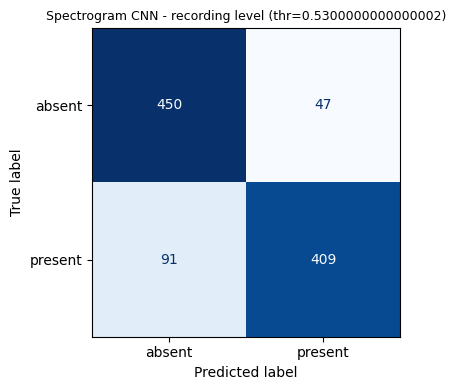

Missed murmurs (FN) : 91
False alarms   (FP) : 47


In [ ]:
cm = confusion_matrix(test_labels, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=["absent", "present"]).plot(
    ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"Spectrogram CNN - recording level (thr={OPT_THRESHOLD})", fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "cnn15_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
tn, fp, fn, tp = cm.ravel()
print(f"Missed murmurs (FN) : {fn}")
print(f"False alarms   (FP) : {fp}")


## Step 14 - ROC Curve

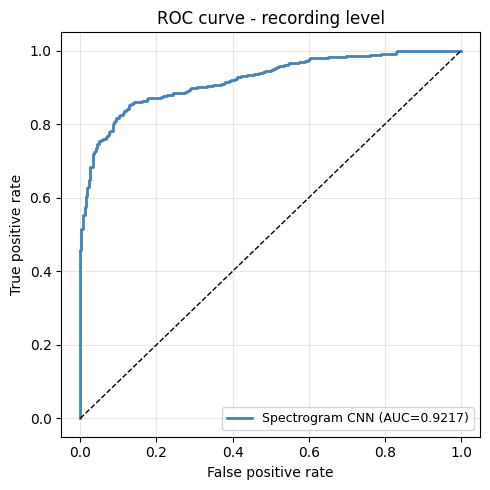

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(test_labels, y_prob)
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fpr, tpr, color="steelblue", lw=2, label=f"Spectrogram CNN (AUC={rec_auc:.4f})")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
ax.set_title("ROC curve - recording level"); ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "cnn15_roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()


## Step 15 - Comparison Table

In [ ]:
print("=" * 60)
print(f"{'Model':<36} {'Acc %':>8} {'AUC':>8}")
print("-" * 60)
print(f"{'RF + XGBoost (hand-crafted features)':<36} {'~74':>8} {'0.74':>8}")
print(f"{'Nb14: 1D CNN, JMD, first 4s':<36} {'73.52':>8} {'0.8113':>8}")
print(f"{'Nb15: 2D CNN, spectrogram, full rec':<36} {rec_acc*100:>8.2f} {rec_auc:>8.4f}")
print("=" * 60)


Model                                   Acc %      AUC
------------------------------------------------------------
RF + XGBoost (hand-crafted features)      ~74     0.74
Nb14: 1D CNN, JMD, first 4s             73.52   0.8113
Nb15: 2D CNN, spectrogram, full rec     86.16   0.9217


## Step 16 - Save Model and Probabilities

In [ ]:
model.save(MODELS_DIR / "1d_cnn_v2.keras")

pd.DataFrame({
    "file"        : test_stems,
    "true_label"  : test_labels,
    "prob_present": y_prob,
    "pred_label"  : y_pred,
}).to_csv(OUTPUTS_DIR / "cnn15_test_probs.csv", index=False)

print("Saved: models/1d_cnn_v2.keras")
print("Saved: outputs/cnn15_test_probs.csv")


Saved: models/1d_cnn_v2.keras
Saved: outputs/cnn15_test_probs.csv
